# Unfold Data

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
from os import path, makedirs
from datetime import datetime
from functools import partial

# local imports
import sys
# sys.path.append('../../../')
sys.path.append('/exp/sbnd/app/users/munjung/xsec/cafpyana_2026Jan17/cafpyana') # absolute path for running on EAF
from pyanalib.split_df_helpers import *
from analysis_village.numucc_1p0pi.variable_configs import VariableConfig
from analysis_village.numucc_1p0pi.utils import *
from analysis_village.numucc_1p0pi.files_config import *
from analysis_village.numucc_1p0pi.constants import *
from analysis_village.unfolding.wienersvd import *
from pyanalib.covariance import *

import matplotlib.pyplot as plt 

import warnings
from pandas.errors import PerformanceWarning
warnings.filterwarnings("ignore", category=PerformanceWarning)

mc_n_split: 1
mc_tot_pot: 1.521e+19
Integrated flux: 2.456e+11
# of targets:  1.3251484770937053e+30
XSEC_UNIT is 0, setting to 1e-38
xsec unit:  1e-38


/exp/sbnd/app/users/munjung/xsec/cafpyana_2026Jan17/cafpyana/analysis_village/numucc_1p0pi/constants.py:56: RuntimeWarning: overflow encountered in scalar multiply
  xsec_unit = 1 / (integrated_flux * NTARGETS)


In [3]:
save_result = False
save_fig = save_result

today_str = datetime.now().strftime("%Y%m%d")
save_fig_dir = path.join(save_fig_base_dir, "unfolding-data-{}".format(today_str))

if save_fig:
    if not path.exists(save_fig_dir):
        makedirs(save_fig_dir)
    print("saving plots in ", save_fig_dir)

In [4]:
ret = get_ana_dfs(option="data_unfolding")
# ret = get_ana_dfs(option="fake_data_test")

mc_hdr_df = ret['hdr']
mc_nu_df = ret['mcnu']
mc_evt_df = ret['evt']

data_evt_df = ret['data']
data_hdr_df = ret['data_hdr']

pot_str = ret['pot_str']
pot_label = ret['pot_label']

Keys: ['/evt_0', '/hdr_0', '/histgenevtdf_0', '/histpotdf_0', '/mcnu_0', '/split']
Reading file with tag aa, mc_n_split: 1
Keys: ['/evt_0', '/hdr_0', '/histgenevtdf_0', '/histpotdf_0', '/mcnu_0', '/split']
Reading file with tag ab, mc_n_split: 1
Keys: ['/evt_0', '/hdr_0', '/histgenevtdf_0', '/histpotdf_0', '/mcnu_0', '/split']
Reading file with tag ac, mc_n_split: 1
data_tot_pot: 4.574e+18
data tot gates : 9.509e+05
mc_tot_pot: 4.562e+19
mc_pot_scale: 1.003e-01


In [5]:
# --- config for Wiener-SVD unfolding ---
C_type = 2
Norm_type = 0.

In [6]:
data_tot_pot = data_hdr_df['pot'].sum()
print("data_tot_pot", data_tot_pot)

data_tot_pot 4.5744274e+18


In [7]:
# fluxfile = "/exp/sbnd/data/users/munjung/flux/sbnd_original_flux.root"

# def get_xsec_unit(tot_pot, 
#                   fluxfile="/exp/sbnd/data/users/munjung/flux/sbnd_original_flux.root", 
#                   detector="SBND"):

#     tot_flux = get_integrated_flux(fluxfile, plot=False)
#     tot_flux = tot_flux * tot_pot
#     print("integrated flux: {:.3e}".format(tot_flux))

#     V_SBND = get_active_volume(detector)
#     # Number of argon nuclei: total mass / mass per nucleus
#     # RHO = density (g/cm^3), V_SBND = volume (cm^3), M_AR = molar mass of Ar (g/mol), N_A = Avogadro's number (nuclei/mol)
#     NTARGETS = (RHO * V_SBND / M_AR) * N_A
#     print("# of argon target nuclei: ", NTARGETS)

#     save_factor = 1e30
#     NTARGETS = NTARGETS / save_factor

#     xsec_unit = 1 / (tot_flux * NTARGETS)

#     xsec_unit = xsec_unit / save_factor
#     print("xsec unit: ", xsec_unit)
#     return float(xsec_unit)

# xsec_unit = get_xsec_unit(data_tot_pot, fluxfile, detector="SBND_face")

# print(xsec_unit)

In [8]:
var_configs = [
    # VariableConfig.all_events(),
            # VariableConfig.muon_momentum(),
            # VariableConfig.muon_direction(),
            # VariableConfig.proton_momentum(),
            # VariableConfig.proton_direction(),
            # # VariableConfig.opening_angle(),
            # VariableConfig.tki_del_alpha(),
            # VariableConfig.tki_del_phi(),
            VariableConfig.tki_del_Tp(),
            # VariableConfig.tki_del_p(),
            # VariableConfig.tki_del_Tp_x(),
            # VariableConfig.tki_del_Tp_y()
            ]

mc_evt_df.loc[mc_evt_df.mc.iscc.isna(), ("mc","iscc")] = 999
data_evt_df[("mc","iscc")] = 999

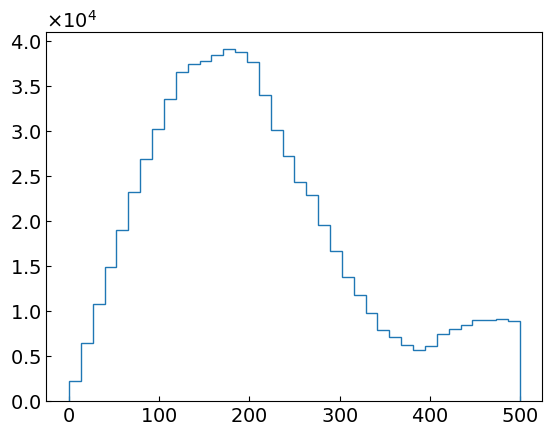

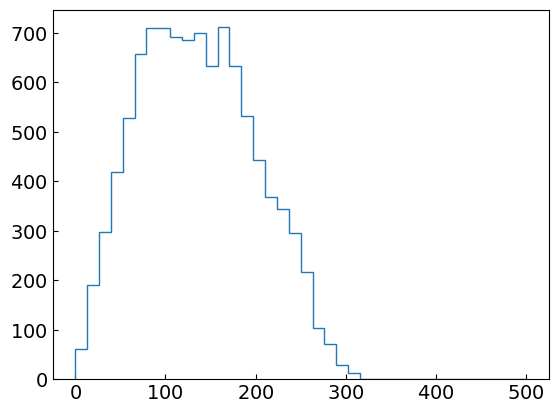

In [18]:
mc_nu_df["r"] = np.sqrt((mc_nu_df.mc.position.x+74)**2 + mc_nu_df.mc.position.y**2)
var = mc_nu_df.r
plt.hist(var, bins=np.linspace(0, 500, 39), histtype="step")
plt.show()

mc_evt_df["r"] = np.sqrt((mc_evt_df.mc.position.x+74)**2 + mc_evt_df.mc.position.y**2)
var = mc_evt_df.r
plt.hist(var, bins=np.linspace(0, 500, 39), histtype="step")
plt.show()

In [162]:
from mycolorpy import colorlist as mcp

def prism_cut(df, r_low, r_high): #cm
    return (df.r > r_low) & (df.r < r_high)

PRISM_colors=mcp.gen_color(cmap="viridis",n=9)
PRISM_labels = ["[0.0$^\circ$, 0.2$^\circ$)","[0.2$^\circ$, 0.4$^\circ$)","[0.4$^\circ$, 0.6$^\circ$)","[0.6$^\circ$, 0.8$^\circ$)","[0.8$^\circ$, 1.0$^\circ$)","[1.0$^\circ$, 1.2$^\circ$)","[1.2$^\circ$, 1.4$^\circ$)","[1.4$^\circ$, 1.6$^\circ$)"]
RINGS = np.array([11000*np.tan(i*np.pi/180) for i in np.linspace(0, 1.6, 9)])
OAA_cuts_numu = {Ri: prism_cut(mc_nu_df, RINGS[Ri], RINGS[Ri+1]) for Ri in range(len(RINGS[:-1]))}
OAA_cuts_numu_evt = {Ri: prism_cut(mc_evt_df, RINGS[Ri], RINGS[Ri+1]) for Ri in range(len(RINGS[:-1]))}

def area_contained_circle(r):
    if r < 120:
        return np.pi * r**2

    elif (r > 120) & (r < 190):
        theta = np.arccos((120)/r)

        ratio = (np.pi - theta) / (np.pi)
        area_circ = np.pi * r**2 * ratio

        bottom = np.sqrt(r**2 - 120**2)
        area_triag = bottom * 120 

        return area_circ + area_triag

    elif (r > 190) & (r < 260):
        theta = np.arcsin(190/r)
        ratio = theta / (np.pi)

        area_circ = np.pi * r**2 * ratio
        area_square = 120 * 380
        bottom = np.sqrt(r**2 - 190**2)
        area_triag = bottom * 190

        return area_circ + area_triag + area_square

    else:
        print("out of range")
        return 0

OAA_volumes_old = {Ri: np.pi * (RINGS[Ri+1]**2 - RINGS[Ri]**2) * 440 for Ri in range(len(RINGS[:-1]))}
OAA_volumes = {Ri: (area_contained_circle(RINGS[Ri+1]) - area_contained_circle(RINGS[Ri])) * 440 for Ri in range(len(RINGS[:-1]))}

out of range
out of range
out of range


In [172]:
print(len(signal_cut(mc_nu_df[OAA_cuts_numu[0]])) / OAA_volumes[0])
print(len(signal_cut(mc_nu_df[OAA_cuts_numu[1]])) / OAA_volumes[1])
print(len(signal_cut(mc_nu_df[OAA_cuts_numu[2]])) / OAA_volumes[2])
print(len(signal_cut(mc_nu_df[OAA_cuts_numu[3]])) / OAA_volumes[3])

# print(len(signal_cut(mc_nu_df[OAA_cuts_numu[0]])) / get_xsec_unit())
# print(len(signal_cut(mc_nu_df[OAA_cuts_numu[1]])) / get_xsec_unit())
# print(len(signal_cut(mc_nu_df[OAA_cuts_numu[2]])) / get_xsec_unit())
# print(len(signal_cut(mc_nu_df[OAA_cuts_numu[3]])) / get_xsec_unit())

DETECTOR:  SBND_nohighyz
0.0012036254840199876
DETECTOR:  SBND_nohighyz
0.001206366776077243
DETECTOR:  SBND_nohighyz
0.0011464972974475724
DETECTOR:  SBND_nohighyz
0.0009514064890485015


In [115]:
def get_xsec_unit(tot_pot, 
                  fluxfile="/exp/sbnd/data/users/munjung/flux/sbnd_original_flux.root", 
                  detector="SBND",
                  volume=None):

    tot_flux = get_integrated_flux(fluxfile, plot=False)
    tot_flux *= tot_pot
    # print("integrated flux: ", tot_flux)

    V_SBND = get_active_volume(detector)
    if volume is not None:
        # print("using custom volume: ", volume)
        V_SBND = volume

    NTARGETS = RHO * V_SBND * (N_A / M_AR) #/ 40 # divide by 40 to make this per-argon nucleus
    # print("# of targets: ", NTARGETS)
    NTARGETS = NTARGETS / 1e30

    xsec_unit = 1 / (tot_flux * NTARGETS)
    xsec_unit = xsec_unit / 1e30
    # # TODO: fix scalar overflow error in python v3.10+
    # if xsec_unit == 0:
    #     print("XSEC_UNIT is 0, setting to 1e-38")
    #     xsec_unit = 1e-38
    # print("xsec unit: ", xsec_unit)
    return xsec_unit

    

In [116]:
var_config = VariableConfig.tki_del_Tp()

mc_pot_scale: 2.791e+00
Integrated flux: 1.615e-08


/tmp/ipykernel_1748984/1736363119.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  this_mc_nu_df["pot_weight"] = np.ones(len(this_mc_nu_df))


mc_pot_scale: 1.000e+00
Integrated flux: 1.615e-08


/tmp/ipykernel_1748984/1736363119.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  this_mc_nu_df["pot_weight"] = np.ones(len(this_mc_nu_df))


mc_pot_scale: 6.075e-01
Integrated flux: 1.615e-08


...

mc_pot_scale: 4.703e-01
Integrated flux: 1.615e-08


/tmp/ipykernel_1748984/1736363119.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  this_mc_nu_df["pot_weight"] = np.ones(len(this_mc_nu_df))


mc_pot_scale: 5.253e-01
Integrated flux: 1.615e-08


/tmp/ipykernel_1748984/1736363119.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  this_mc_nu_df["pot_weight"] = np.ones(len(this_mc_nu_df))


Integrated flux: 1.615e-08
DETECTOR:  SBND_nohighyz
DETECTOR:  SBND_nohighyz
DETECTOR:  SBND_nohighyz
DETECTOR:  SBND_nohighyz
DETECTOR:  SBND_nohighyz
DETECTOR:  SBND_nohighyz
DETECTOR:  SBND_nohighyz


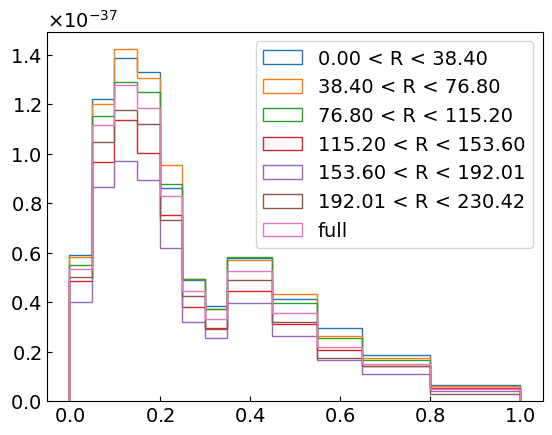

In [177]:
fluxfile = "/exp/sbnd/data/users/munjung/flux/sbnd_original_flux.root"

df_list = []
labels_list = []
xsec_unit_list = []
for oidx, OAA_cut in enumerate(OAA_cuts_numu.keys()):
    if oidx > 5:
        continue

    this_mc_nu_df = mc_nu_df[OAA_cuts_numu[OAA_cut]]
    this_mc_hdr_df = mc_hdr_df.loc[this_mc_nu_df.reset_index(level=[2]).index.unique()]

    mc_tot_pot = this_mc_hdr_df['pot'].sum()
    mc_tot_pot = this_mc_hdr_df['pot'].sum()
    mc_pot_scale = data_tot_pot / mc_tot_pot
    print("mc_pot_scale: %.3e" %(mc_pot_scale))
    # this_mc_nu_df["pot_weight"] = mc_pot_scale * np.ones(len(this_mc_nu_df))
    this_mc_nu_df["pot_weight"] = np.ones(len(this_mc_nu_df))
    df_list.append(this_mc_nu_df)
    labels_list.append(f"{RINGS[oidx]:.2f} < R < {RINGS[oidx+1]:.2f}")

    # xsec_unit = get_xsec_unit(data_tot_pot, fluxfile, detector="SBND", volume=OAA_volumes[OAA_cut])
    xsec_unit = get_xsec_unit(data_tot_pot, fluxfile, detector="SBND", volume=OAA_volumes[OAA_cut])
    xsec_unit_list.append(xsec_unit)

mc_nu_df["pot_weight"] = np.ones(len(mc_nu_df))
df_list.append(mc_nu_df[InFV(mc_nu_df.mc.position, det="SBND_nohighyz")])
labels_list.append("full")
xsec_unit = get_xsec_unit(data_tot_pot, fluxfile, detector="SBND_nohighyz")
xsec_unit_list.append(xsec_unit)

for didx, df in enumerate(df_list):
    nudf_signal = signal_cut(df)
    var_allmc, wgt_allmc = get_clipped_evts(nudf_signal, var_config.var_nu_col, var_config.bins)
    nevts_allmc, _ = np.histogram(var_allmc, weights=wgt_allmc, bins=var_config.bins)

    # ret_signal_hists = signal_hists(mc_evt_df, mc_nu_df, var_config, mode="unfold", return_data=True, plot=False)
    # model    = ret_signal_hists["nevts_allmc"] * xsec_unit
    model = nevts_allmc * xsec_unit_list[didx]
    plt.hist(var_config.bin_centers, var_config.bins, weights=model, label=labels_list[didx], histtype="step")

# gen_output = np.array([5.63214194e-39, 1.17155555e-38, 1.31107044e-38, 1.17549445e-38,
#        8.07158591e-39, 3.75338349e-39, 2.49488035e-39, 3.87276622e-39,
#        2.50022947e-39, 1.52206910e-39, 1.02922020e-39, 3.50367662e-40])
# plt.hist(var_config.bin_centers, var_config.bins, weights=gen_output, color="red", label="GENIE", histtype="step")

plt.legend()
plt.show()

In [ ]:
fluxfile = "/exp/sbnd/data/users/munjung/flux/sbnd_original_flux.root"

df_list = []
labels_list = []
xsec_unit_list = []
for z_lo, z_hi in zip([50], [100]):
    this_mc_nu_df = mc_nu_df[(mc_nu_df.mc.position.z < z_hi) & (mc_nu_df.mc.position.z > z_lo)]
    this_mc_evt_df = mc_evt_df[(mc_evt_df.mc.position.z < z_hi) & (mc_evt_df.mc.position.z > z_lo)]

    this_mc_hdr_df = mc_hdr_df.loc[this_mc_evt_df.index.unique()]
    mc_tot_pot = this_mc_hdr_df['pot'].sum()
    mc_pot_scale = data_tot_pot / mc_tot_pot
    print("mc_pot_scale: %.3e" %(mc_pot_scale))
    this_mc_nu_df["pot_weight"] = mc_pot_scale * np.ones(len(this_mc_nu_df))
    df_list.append(this_mc_nu_df)
    labels_list.append(f"z_lo={z_lo}, z_hi={z_hi}")

    xsec_unit = get_xsec_unit(data_tot_pot, fluxfile, detector="SBND_face")
    xsec_unit_list.append(xsec_unit)

df_list.append(mc_nu_df)
labels_list.append("full")
xsec_unit = get_xsec_unit(data_tot_pot, fluxfile, detector="SBND_nohighyz")
xsec_unit_list.append(xsec_unit)

for df, label in zip(df_list, labels_list):
    nudf_signal = signal_cut(df)
    var_allmc, wgt_allmc = get_clipped_evts(nudf_signal, var_config.var_nu_col, var_config.bins)
    nevts_allmc, _ = np.histogram(var_allmc, weights=wgt_allmc, bins=var_config.bins)

    ret_signal_hists = signal_hists(mc_evt_df, mc_nu_df, var_config, mode="unfold", return_data=True, plot=False)
    model    = ret_signal_hists["nevts_allmc"] * xsec_unit
    plt.hist(var_config.bin_centers, var_config.bins, weights=model, label=label, histtype="step")

# gen_output = np.array([5.63214194e-39, 1.17155555e-38, 1.31107044e-38, 1.17549445e-38,
#        8.07158591e-39, 3.75338349e-39, 2.49488035e-39, 3.87276622e-39,
#        2.50022947e-39, 1.52206910e-39, 1.02922020e-39, 3.50367662e-40])
# plt.hist(var_config.bin_centers, var_config.bins, weights=gen_output, color="red", label="GENIE", histtype="step")

plt.legend()
plt.show()

In [67]:
eps = 1e-8
ratio = True
approval = "internal"
textloc = [0.05, 0.55]
ax_ylim_ratio = 1.6
breakdown_type = "topology"

unfolding_plotter = partial(
    overlay_hists,
    breakdown_type=breakdown_type,
    mc_df=mc_evt_df,
    data_df=data_evt_df,
    intime_df=None,
    ax_ylim_ratio=ax_ylim_ratio,
    ratio=ratio,
    textloc=textloc,
    approval=approval,
    save_fig=save_fig, 
)

In [68]:
for var_config in var_configs:

    syst_unc, syst_cov_matrix = get_syst_unc(var_config, plot=False, save_fig=False)

    plot_labels_hist = [var_config.var_labels[1], pot_label, ""]
    ret = unfolding_plotter(var_config=var_config,
                            plot_labels=plot_labels_hist,
                            syst=syst_unc,
                            save_name=path.join(save_fig_dir, "{}_{}".format(var_config.var_save_name, breakdown_type)))
                            
    tot_frac_cov = syst_cov_matrix + np.diag(1/ret["total_data"])
    tot_cov = cov_from_fraccov(tot_frac_cov, ret["total_mc"])
    ret_chi2 = get_chi2(ret["total_data"], ret["total_mc"], tot_cov)

    evtdf_signal = mc_evt_df[mc_evt_df.topo_categ == 1]
    nudf_signal = mc_nu_df[mc_nu_df.topo_categ == 1]
    ret_signal_hists = signal_hists(mc_evt_df, mc_nu_df, var_config, mode="unfold", return_data=True, plot=False)

    save_fig_name = "{}/{}-reco_vs_true".format(save_fig_dir, var_config.var_save_name)
    if len(var_config.bins) == 2:
        reco_vs_true = np.array([[1.0]])
    else:
        reco_vs_true, _, _ = np.histogram2d(ret_signal_hists["var_sel_truth"], 
                                            ret_signal_hists["var_sel_reco"], 
                                            weights=ret_signal_hists["wgt_sel_reco"],
                                            bins=var_config.bins)

    plot_heatmap(reco_vs_true, 
                var_config.bins, 
                plot_labels=[var_config.var_labels[2], var_config.var_labels[1], "Smearing"],
                verbose=True,
                save_fig=save_fig, 
                save_name=save_fig_name)

    eff = ret_signal_hists["nevts_sel_truth"] / ret_signal_hists["nevts_allmc"]
    print(eff)

    save_fig_name = "{}/{}-response_matrix".format(save_fig_dir, var_config.var_save_name)
    response = get_response_matrix(reco_vs_true, eff)

    plot_heatmap(response, 
                var_config.bins, 
                plot_labels=[var_config.var_labels[2], var_config.var_labels[1], "Response"],
                save_fig=save_fig, 
                verbose=True,
                save_name=save_fig_name)


    nevts_sel_data = ret["total_data"] - ret["total_mc_bkgd"] 
    measured = nevts_sel_data * xsec_unit  # bkgd-subtracted data
    model    = ret_signal_hists["nevts_allmc"] * xsec_unit
    Covariance = cov_from_fraccov(syst_cov_matrix, ret_signal_hists["nevts_sel_reco"]) * xsec_unit**2 
    unfold = WienerSVD(response, model, measured, Covariance*1.1, C_type, Norm_type)
    # print(unfold.keys())
    # decomp_cov = Matrix_Decomp(model, unfold['SystUnfoldCov'])


# Compare to GENIE output

In [52]:
save_results_dir = "/exp/sbnd/data/users/munjung/xsec/DATA_RESULTS"
nevts_dict = np.load(f"{save_results_dir}/{var_config.var_save_name}-nevts_dict.npy", allow_pickle=True).item()

In [53]:
model

In [69]:
models = {"SBN Baseline model": model,  "AR23": nevts_dict["GENIE AR23"]}
save_name = f"{save_fig_dir}/{var_config.var_save_name}-unfolded_event_rates-DATA"

# if measured
measured[measured <=0] = 1

plot_unfolded_result(unfold, 
                    measured, 
                    models, 
                    var_config,
                    # chi2_list = [float(ret_chi2[0])],
                    xsec_unit=xsec_unit,
                    save_fig=save_fig, 
                    save_name=save_name,
                    data=True,
                    closure_test=False)

save_fig_name = "{}/{}-{}-add_smear".format(save_fig_dir, var_config.var_save_name, "data")
plot_heatmap(unfold["AddSmear"], 
            var_config.bins, 
            plot_labels=[var_config.var_labels[2], var_config.var_labels[1], "$A_c$"],
            save_fig=save_fig, 
            save_name=save_fig_name)

In [14]:
save_results_dir = "/exp/sbnd/data/users/munjung/xsec/DATA_RESULTS"
np.save(f"{save_results_dir}/{var_config.var_save_name}-AddSmear.npy", unfold["AddSmear"])